
# UMBC Soccer: Expected Goals (xG), Expected Goals Against (xGA), and xGD Analysis (2023–2025)

## Purpose

This notebook combines UMBC’s attacking (xG) and defensive (xGA) models to produce
**expected goal difference (xGD)** at the match level.

xGD provides a single, context-adjusted measure of match control and performance that:
- is less noisy than scorelines,
- separates process from outcomes,
- supports tactical evaluation across opponents and competitions.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import PoissonRegressor




## 1) Load match-level data (2023–2025)

We load UMBC match CSVs for multiple seasons and combine them into one table.




In [18]:
CSV_FILES = [
    "team_match_2023.csv",
    "team_match_2024.csv",
    "team_match_2025.csv",
]

dfs = []
for f in CSV_FILES:
    df = pd.read_csv(f)
    df.columns = [c.strip() for c in df.columns]

    # infer season from filename if missing
    if "season" not in df.columns:
        import re
        m = re.search(r"(20\d{2})", f)
        if m:
            df["season"] = int(m.group(1))

    dfs.append(df)

matches = pd.concat(dfs, ignore_index=True)

# Parse date and sort
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
matches = matches.sort_values("date").reset_index(drop=True)

matches.head()



,season,date,home_away,opponent,result,goals_for,goals_against,attendance,shots,shots_on_goal,yellow,red,opp_shots,opp_shots_on_goal
0,2023.0,2023-08-24,Home,George Mason,W,4,3,824,14,7,4,0,9,4
1,NaN,2023-08-28,Home,Old Dominion,T,1,1,2891,17,7,3,0,10,4
2,NaN,2023-09-01,Home,Liberty,W,3,0,972,9,5,0,0,15,4
3,NaN,2023-09-03,Home,Howard,W,2,0,1021,18,12,0,0,6,2
4,NaN,2023-09-12,Away,Hofstra,L,0,2,303,6,3,2,1,12,5


## 2) Feature engineering (guaranteed block)

This block *guarantees* that the following columns exist before modeling:

- `home`
- `shot_accuracy`
- `is_conference`
- `opp_strength`
- `conf_x_opp`

This prevents KeyErrors if you restart your kernel or run cells out of order.



In [19]:
# --------------------------------------------------------
# GUARANTEED FEATURE BLOCK (prevents KeyErrors)
# --------------------------------------------------------

# Ensure date is datetime (needed for pre-match opponent strength)
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")

# 1) Home flag
if "home" not in matches.columns:
    # If your dataset uses a different column name than "home_away", change it here:
    matches["home"] = (matches["home_away"].astype(str).str.strip().str.lower() == "home").astype(int)

# 2) Shot accuracy
if "shot_accuracy" not in matches.columns:
    matches["shot_accuracy"] = np.where(
        matches["shots"].fillna(0) > 0,
        matches["shots_on_goal"] / matches["shots"],
        0.0
    ).astype(float)

# 3) Conference indicator (America East)
if "is_conference" not in matches.columns:
    CONFERENCE_OPPONENTS = {
        "Vermont", "Bryant", "Binghamton", "NJIT",
        "Umass Lowell", "New Hampshire", "Ualbany", "Maine"
    }
    matches["opponent"] = matches["opponent"].astype(str).str.strip()
    matches["is_conference"] = matches["opponent"].isin(CONFERENCE_OPPONENTS).astype(int)

# 4) Opponent strength (NO leakage + shrinkage)
#    Uses only PRIOR UMBC results vs that opponent
if "opp_strength" not in matches.columns:
    matches = matches.sort_values("date").reset_index(drop=True)

    m_prior = 3.0  # shrinkage strength (1–5 typical)
    strength = []

    for i, row in matches.iterrows():
        prev = matches[(matches["opponent"] == row["opponent"]) & (matches["date"] < row["date"])]

        if len(prev) == 0:
            strength.append(0.0)
        else:
            gd_prev = (prev["goals_for"] - prev["goals_against"]).astype(float)
            s = -(gd_prev.sum()) / (len(gd_prev) + m_prior)
            strength.append(float(s))

    matches["opp_strength"] = strength

# 5) Interaction term
if "conf_x_opp" not in matches.columns:
    matches["conf_x_opp"] = matches["is_conference"] * matches["opp_strength"]

print("✅ Ready columns:",
      [c for c in ["home","shot_accuracy","is_conference","opp_strength","conf_x_opp"] if c in matches.columns])

matches[["date","season","opponent","home_away","home","is_conference","opp_strength","conf_x_opp","shots","shots_on_goal","shot_accuracy"]].head(10)




✅ Ready columns: ['home', 'shot_accuracy', 'is_conference', 'opp_strength', 'conf_x_opp']


,date,season,opponent,home_away,home,is_conference,opp_strength,conf_x_opp,shots,shots_on_goal,shot_accuracy
0,2023-08-24,2023.0,George Mason,Home,1,0,0.0,0.0,14,7,0.500000
1,2023-08-28,NaN,Old Dominion,Home,1,0,0.0,0.0,17,7,0.411765
2,2023-09-01,NaN,Liberty,Home,1,0,0.0,0.0,9,5,0.555556
3,2023-09-03,NaN,Howard,Home,1,0,0.0,0.0,18,12,0.666667
4,2023-09-12,NaN,Hofstra,Away,0,0,0.0,0.0,6,3,0.500000
5,2023-09-16,NaN,Cornell,Home,1,0,0.0,0.0,6,4,0.666667
6,2023-09-19,NaN,American,Home,1,0,0.0,0.0,18,4,0.222222
7,2023-09-23,NaN,Ualbany,Away,0,1,0.0,0.0,9,3,0.333333
8,2023-09-30,NaN,Bryant,Home,1,1,0.0,0.0,6,1,0.166667
9,2023-10-03,NaN,Navy,Home,1,0,0.0,0.0,21,14,0.666667


## 3) Attack model: Contextual xG (xG_ctx)

I fit a Poisson regression for **goals_for**, using:

- shots_on_goal
- home
- shot_accuracy
- opponent strength
- conference indicator
- conference × opponent strength interaction

This produces **xG_ctx**, a context-adjusted estimate of how many goals UMBC *should* score.



In [21]:
X_attack = matches[[
    "shots_on_goal",
    "home",
    "shot_accuracy",
    "opp_strength",
    "is_conference",
    "conf_x_opp"
]].copy()

y_attack = matches["goals_for"].astype(float)

attack_model = PoissonRegressor(alpha=0.0, max_iter=10000)
attack_model.fit(X_attack, y_attack)

matches["xG_ctx"] = attack_model.predict(X_attack)

attack_coef = dict(zip(X_attack.columns, attack_model.coef_))
attack_mult = {k: float(np.exp(v)) for k, v in attack_coef.items()}

print("ATTACK Intercept:", attack_model.intercept_)
print("ATTACK Coefficients:", attack_coef)
print("\nATTACK Multipliers (exp(coef)):", attack_mult)



ATTACK Intercept: -0.7639493770140006
ATTACK Coefficients: {'shots_on_goal': 0.1248628848117557, 'home': 0.1087044054866404, 'shot_accuracy': 0.5844200414679641, 'opp_strength': 0.001464732273064716, 'is_conference': -0.07471550053702622, 'conf_x_opp': -0.8320436389699646}

ATTACK Multipliers (exp(coef)): {'shots_on_goal': 1.1329930918548097, 'home': 1.1148327631836592, 'shot_accuracy': 1.7939502671188141, 'opp_strength': 1.0014658055173218, 'is_conference': 0.9280074664015048, 'conf_x_opp': 0.4351590689584609}


## 4) Defensive model: Contextual xGA (xGA_ctx)

To model expected goals conceded, we need opponent attacking pressure.

**Required column:**
- `opp_shots_on_goal`

If your CSVs do not include this column yet, the notebook will:
- skip the defensive model cleanly, and
- still allow you to compute and interpret xG_ctx.


In [23]:
if "opp_shots_on_goal" in matches.columns:
    X_def = matches[[
        "opp_shots_on_goal",
        "home",
        "opp_strength",
        "is_conference",
        "conf_x_opp"
    ]].copy()

    y_def = matches["goals_against"].astype(float)

    def_model = PoissonRegressor(alpha=0.0, max_iter=10000)
    def_model.fit(X_def, y_def)

    matches["xGA_ctx"] = def_model.predict(X_def)

    def_coef = dict(zip(X_def.columns, def_model.coef_))
    def_mult = {k: float(np.exp(v)) for k, v in def_coef.items()}

    print("DEFENSE Intercept:", def_model.intercept_)
    print("DEFENSE Coefficients:", def_coef)
    print("\nDEFENSE Multipliers (exp(coef)):", def_mult)
else:
    matches["xGA_ctx"] = np.nan
    print("Missing opp_shots_on_goal -> xGA_ctx not computed yet.")



DEFENSE Intercept: -0.661993555018419
DEFENSE Coefficients: {'opp_shots_on_goal': 0.15900885172207274, 'home': 0.18442050870728602, 'opp_strength': 1.102545536217267, 'is_conference': -0.20891109005701533, 'conf_x_opp': -0.8181511519161478}

DEFENSE Multipliers (exp(coef)): {'opp_shots_on_goal': 1.1723483239363253, 'home': 1.2025213875058773, 'opp_strength': 3.0118229787563644, 'is_conference': 0.8114673799546763, 'conf_x_opp': 0.44124669894100343}


## 5) Compute xGD and compare to actual goal differential

Definitions:
- GD = goals_for − goals_against
- xGD = xG_ctx − xGA_ctx

xGD is best interpreted as a measure of **match control**.



In [24]:
matches["GD"] = matches["goals_for"] - matches["goals_against"]

# Only compute xGD where xGA_ctx exists
matches["xGD"] = matches["xG_ctx"] - matches["xGA_ctx"]

matches[["date","season","opponent","home_away","goals_for","goals_against","GD","xG_ctx","xGA_ctx","xGD"]].head(12)



,date,season,opponent,home_away,goals_for,goals_against,GD,xG_ctx,xGA_ctx,xGD
0,2023-08-24,2023.0,George Mason,Home,4,3,1,1.666966,1.171708,0.495258
1,2023-08-28,NaN,Old Dominion,Home,1,1,0,1.583185,1.171708,0.411477
2,2023-09-01,NaN,Liberty,Home,3,0,3,1.341445,1.171708,0.169737
3,2023-09-03,NaN,Howard,Home,2,0,2,3.430558,0.852523,2.578035
4,2023-09-12,NaN,Hofstra,Away,0,2,-2,0.907419,1.142308,-0.234889
5,2023-09-16,NaN,Cornell,Home,2,1,1,1.263417,2.213329,-0.949912
6,2023-09-19,NaN,American,Home,1,3,-2,0.974411,1.610396,-0.635985
7,2023-09-23,NaN,Ualbany,Away,2,1,1,0.763937,0.926946,-0.163008
8,2023-09-30,NaN,Bryant,Home,0,0,0,0.601882,0.811024,-0.209142
9,2023-10-03,NaN,Navy,Home,4,4,0,4.403716,1.373650,3.030067


## 6) Tactical diagnostic: xGD vs GD

This plot helps identify:
- deserved wins/losses
- lucky wins / unlucky losses
- matches to review in film

Quadrants:
- **xGD > 0, GD < 0:** played well, lost (execution/variance)
- **xGD < 0, GD > 0:** played poorly, won (fragile win)



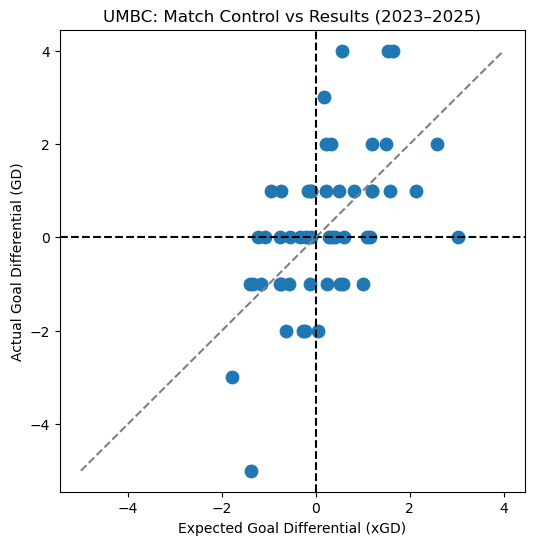

In [25]:
if matches["xGD"].notna().any():
    plt.figure(figsize=(6,6))
    plt.scatter(matches["xGD"], matches["GD"], s=80)
    plt.axhline(0, linestyle="--", color="black")
    plt.axvline(0, linestyle="--", color="black")

    lo = min(matches["xGD"].min(), matches["GD"].min())
    hi = max(matches["xGD"].max(), matches["GD"].max())
    plt.plot([lo, hi], [lo, hi], linestyle="--", color="gray")

    plt.xlabel("Expected Goal Differential (xGD)")
    plt.ylabel("Actual Goal Differential (GD)")
    plt.title("UMBC: Match Control vs Results (2023–2025)")
    plt.show()
else:
    print("xGD not available yet — add opp_shots_on_goal to compute xGA_ctx.")


## 7) Conference vs non-conference summaries

This section compares performance and match control in:
- non-conference games (often experimentation + different opponent styles)
- conference games (familiar opponents + higher tactical constraints)


In [26]:
cols = ["goals_for","goals_against","GD","xG_ctx"]
if matches["xGD"].notna().any():
    cols += ["xGA_ctx","xGD"]

summary = matches.groupby("is_conference")[cols].agg(["count","mean","median","std"])
summary.index = ["Non-Conference","Conference"]
summary



goals_for                            goals_against            \
                   count      mean median       std         count      mean   
Non-Conference        28  1.571429    1.0  1.476446            28  1.392857   
Conference            24  1.250000    1.0  0.944089            24  1.041667   

                                   GD            ...    xG_ctx            \
               median       std count      mean  ...    median       std   
Non-Conference    1.0  1.370031    28  0.178571  ...  1.238663  0.865407   
Conference        1.0  1.122078    24  0.208333  ...  1.125510  0.576194   

               xGA_ctx                                 xGD            \
                 count      mean    median       std count      mean   
Non-Conference      28  1.392852  1.171708  0.630274    28  0.178559   
Conference          24  1.041660  0.860167  0.581265    24  0.208386   

                                    
                  median       std  
Non-Conference  0.192097  1.174101  
Conference      0.133104  0.913929  

[2 rows x 24 columns]

## 8) Match case studies 

We generate three lists:
1) Best matches by xGD (strong process)
2) Worst matches by xGD (weak process)
3) Most misleading results (GD − xGD) to identify high-variance matches



In [27]:
if matches["xGD"].notna().any():
    cols = ["date","season","opponent","home_away","goals_for","goals_against","GD","xG_ctx","xGA_ctx","xGD"]

    print(" Best matches by xGD (best overall control):")
    display(matches.sort_values("xGD", ascending=False)[cols].head(8))

    print(" Worst matches by xGD (worst overall control):")
    display(matches.sort_values("xGD", ascending=True)[cols].head(8))

    matches["result_gap"] = matches["GD"] - matches["xGD"]
    print(" Most misleading results (GD - xGD):")
    display(matches.sort_values("result_gap", ascending=False)[cols + ["result_gap"]].head(8))
else:
    print("xGD not available yet — add opp_shots_on_goal to compute xGA_ctx.")



✅ Best matches by xGD (best overall control):


,date,season,opponent,home_away,goals_for,goals_against,GD,xG_ctx,xGA_ctx,xGD
9,2023-10-03,NaN,Navy,Home,4,4,0,4.403716,1.373650,3.030067
3,2023-09-03,NaN,Howard,Home,2,0,2,3.430558,0.852523,2.578035
17,2024-08-26,NaN,Howard,Home,3,2,1,2.928997,0.791519,2.137478
21,2024-09-13,NaN,Saint Joseph's,Home,4,0,4,2.652206,0.999454,1.652752
38,2025-09-01,NaN,Howard,Home,1,0,1,2.027337,0.439955,1.587382
49,2025-10-31,NaN,Binghamton,Home,4,0,4,1.983716,0.436625,1.547092
24,2024-09-28,NaN,Binghamton,Away,2,0,2,2.171084,0.674436,1.496648
10,2023-10-07,NaN,Umass Lowell,Away,2,1,1,1.781242,0.575287,1.205956


 Worst matches by xGD (worst overall control):


,date,season,opponent,home_away,goals_for,goals_against,GD,xG_ctx,xGA_ctx,xGD
11,2023-10-14,NaN,New Hampshire,Home,1,4,-3,1.108575,2.893924,-1.785349
22,2024-09-17,NaN,American,Away,3,4,-1,1.802609,3.194243,-1.391634
25,2024-10-01,NaN,Drexel,Home,0,5,-5,1.213910,2.594793,-1.380883
34,2024-11-13,NaN,Vermont,Away,1,2,-1,1.173940,2.517947,-1.344007
51,2025-11-08,NaN,New Hampshire,Away,0,0,0,0.316435,1.539956,-1.223521
15,2023-11-04,NaN,Binghampton,Home,0,1,-1,1.039784,2.213329,-1.173545
20,2024-09-06,NaN,Old Dominion,Away,1,1,0,1.071925,2.157793,-1.085868
5,2023-09-16,NaN,Cornell,Home,2,1,1,1.263417,2.213329,-0.949912


 Most misleading results (GD - xGD):


,date,season,opponent,home_away,goals_for,goals_against,GD,xG_ctx,xGA_ctx,xGD,result_gap
18,2024-08-30,NaN,Niagara,Home,4,0,4,2.176939,1.610396,0.566543,3.433457
2,2023-09-01,NaN,Liberty,Home,3,0,3,1.341445,1.171708,0.169737,2.830263
49,2025-10-31,NaN,Binghamton,Home,4,0,4,1.983716,0.436625,1.547092,2.452908
21,2024-09-13,NaN,Saint Joseph's,Home,4,0,4,2.652206,0.999454,1.652752,2.347248
5,2023-09-16,NaN,Cornell,Home,2,1,1,1.263417,2.213329,-0.949912,1.949912
48,2025-10-25,NaN,Umass Lowell,Away,2,0,2,0.758268,0.543478,0.214790,1.785210
31,2024-11-01,NaN,Bryant,Away,1,0,1,0.539885,1.273995,-0.734109,1.734109
37,2025-08-29,NaN,Niagara,Home,3,1,2,1.056813,0.734880,0.321933,1.678067


## Tactical Takeaways & Match Control Insights (2023–2025)

This section synthesizes the **xG / xGA models, xGD case studies, and conference context**
to translate model outputs into **actionable tactical insight**.

---

### 1. Defensive Performance: Goals Against vs xGA

The scatter plot of **Actual Goals Against vs Expected Goals Against (xGA_ctx)** shows:

- A **moderate spread around the diagonal**, indicating:
  - xGA captures defensive exposure reasonably well,
  - but individual matches still contain variance (finishing, goalkeeping, game state).

**Key observation:**
- Several matches fall **above the diagonal** (goals conceded > xGA):
  - Indicates matches where UMBC conceded **more than expected**, likely driven by:
    - defensive errors,
    - transition breakdowns,
    - opponent overperformance.
- Matches **below the diagonal** reflect:
  - strong defensive execution,
  - shot suppression or strong goalkeeping.

**Tactical implication:**  
xGA is a useful baseline for evaluating defensive structure, but post-match review is still required
to identify *why* goals exceeded expectations.

---

### 2. Best Matches by xGD (Strong Match Control)

Matches with the **highest xGD** represent games where UMBC consistently controlled play,
regardless of final score.

Notable patterns among top xGD matches:
- High xG_ctx paired with **low xGA_ctx**
- Mostly **home matches**
- Repeated strong performances vs the same opponents (e.g., Howard, Binghamton)

**Example insights:**
- *UMBC vs Navy (2023)*:  
  - GD = 0 (4–4 draw)
  - xGD ≈ +3.0  
  → Strong attacking dominance, defensive instability masked the quality of performance.
- *UMBC vs Howard (multiple seasons)*:  
  - Consistently high xGD  
  → Tactical approach vs Howard reliably generates chances and limits threat.

**Tactical takeaway:**  
These matches are ideal **reference games** for:
- successful attacking structures,
- effective pressing or buildup patterns,
- lineup combinations that sustain territorial control.

---

### 3. Worst Matches by xGD (Loss of Control)

Low xGD matches highlight games where UMBC struggled structurally, even when results appear close.

Common features of poor xGD matches:
- xGA_ctx > xG_ctx
- Often **away matches**
- Frequently **conference opponents**

**Example insights:**
- *UMBC vs New Hampshire (Home & Away)*:
  - Consistently negative xGD
  - Indicates difficulty breaking down a familiar, compact opponent.
- *UMBC vs Drexel (2024)*:
  - Heavy loss with xGD ≈ −1.38  
  → Defensive exposure exceeded attacking output throughout the match.

**Tactical takeaway:**  
These matches should be prioritized for:
- defensive shape review,
- transition defense analysis,
- adjustments against conference opponents with tactical familiarity.

---

### 4. Misleading Results (GD − xGD)

Matches with a large **GD − xGD gap** indicate high variance outcomes.

#### Overperforming Results (Positive GD − xGD)
- High scorelines with modest xGD
- Suggest:
  - finishing overperformance,
  - opponent defensive errors,
  - game states that inflated results.

**Examples:**
- Niagara (2024 & 2025)
- Saint Joseph’s (2024)

**Caution:**  
These wins may not be repeatable without similar execution efficiency.

---

#### Underperforming Results (Negative GD − xGD)
- Good xGD but weak results
- Suggest:
  - poor finishing,
  - goalkeeping variance,
  - late-game defensive lapses.

**Example:**
- Cornell (2023):  
  - xGD ≈ −0.95 but narrow loss  
  → Match closer than result suggests.

**Tactical takeaway:**  
These games indicate **process is sound**, but execution or game management failed.

---

### 5. Conference vs Non-Conference Patterns

| Context | Mean xGD | Std Dev |
|------|--------|--------|
| Non-Conference | ≈ +0.18 | Higher |
| Conference | ≈ +0.21 | Lower |

**Interpretation:**
- Average xGD is similar across contexts,
- But **conference matches show lower variance**, meaning:
  - tighter games,
  - fewer extreme performances,
  - greater tactical familiarity.

This aligns with earlier findings that:
- **Conference opponent strength interacts more strongly with xG/xGA**
- Strong conference opponents suppress attacking output and increase defensive exposure.

---

### 6. Overall Tactical Conclusions

1. **Chance creation is the primary driver of success**
   - High xGD consistently aligns with dominant performances.
2. **Conference play increases tactical constraints**
   - Familiar opponents reduce variance and punish structural mistakes.
3. **xGD is a better evaluation tool than scoreline alone**
   - Separates performance quality from outcome noise.
4. **Best and worst xGD matches provide a roadmap**
   - Best xGD → templates to replicate
   - Worst xGD → scenarios requiring tactical adjustment

---

### How to Use This Moving Forward

- Use **xGD leaderboards** to select film for tactical meetings.
- Track xGD trends over time to evaluate tactical changes.
- Pair xGD with qualitative review (pressing success, buildup shape, defensive transitions).
- Extend this framework with:
  - player-level xG/xGA contribution,
  - game state variables,
  - opponent shot quality once available.

This xGD framework provides a **process-driven lens** for evaluating UMBC’s performance beyond results.
